In [1]:
import os
import pandas as pd     
import ast

In [2]:
import ast, unicodedata
import pandas as pd

def _clean(s):
    s = unicodedata.normalize('NFKC', str(s))
    return (s.replace('\u200b','')
             .replace('\ufeff','')
             .replace('\xa0',' ')
             .strip())

def _find_column(df, name):
    # exact first
    if name in df.columns: 
        return name
    # normalize and map
    clean_map = {col: _clean(col) for col in df.columns}
    rev = {}
    for k, v in clean_map.items():
        # keep first occurrence
        rev.setdefault(v.lower(), k)
    cname = _clean(name).lower()
    if cname in rev:
        return rev[cname]
    # fallback: partial match on cleaned text
    hits = [orig for orig, c in clean_map.items() if _clean(name).lower() in c.lower()]
    if len(hits) == 1:
        return hits[0]
    # last resort: show close options
    raise KeyError(f"Column not found: {name!r}. Did you mean one of: {hits or list(df.columns)}")

def _try_eval(x):
    if isinstance(x, str):
        s = x.strip()
        if s and s[0] in '{[' and s[-1] in '}]':
            try:
                v = ast.literal_eval(s)
                return v
            except Exception:
                return x
    return x

def split_dict_column(df, column_name, prefix=None, drop_original=True):
    """
    Splits a column of dictionary-like strings into separate columns.
    """
    col = _find_column(df, column_name)

    if prefix is None:
        prefix = _clean(col).replace(":", "").replace(" ", "_")

    # convert strings to dicts/lists when appropriate
    df[col] = df[col].apply(_try_eval)

    # expand dicts; leave non-dicts as-is
    expanded_cols = df[col].apply(lambda v: v if isinstance(v, dict) else {})
    expanded_cols = pd.DataFrame(expanded_cols.tolist())

    if expanded_cols.empty:
        # nothing to expand; return unchanged (or still drop original if asked)
        return df.drop(columns=[col]) if drop_original else df

    expanded_cols = expanded_cols.add_prefix(f"{prefix}_")
    out = pd.concat([df, expanded_cols], axis=1)

    if drop_original:
        out = out.drop(columns=[col])

    return out


In [3]:
def fix_json_file(input_path, output_path):
    with open(input_path, 'r', encoding='utf-8') as infile:
        content = infile.read().strip()

    # If it's already a proper JSON array, do nothing and just copy
    if content.startswith('[') and content.endswith(']'):
        with open(output_path, 'w', encoding='utf-8') as outfile:
            outfile.write(content)
        return

    # Remove trailing comma if it exists
    if content.endswith(','):
        content = content[:-1].rstrip()

    # Wrap in brackets to form a valid JSON array
    content = f'[{content}]'

    with open(output_path, 'w', encoding='utf-8') as outfile:
        outfile.write(content)

In [4]:
def get_csv(path):
    #csv_path = path.split(os.sep)[-1].replace('.json','.csv')

    dataset = path.split(os.sep)[-1].split("_")[0]
    model = path.split(os.sep)[-1].split("_")[1]

    fix_json_file(path,path)
    result_file = pd.read_json(os.path.join(path))
    result_file.to_csv("temp.csv", index=False)
    result_file = pd.read_csv("temp.csv")

    print(result_file.columns)
    
    result_file = split_dict_column(result_file, "LinkTeller unlearn with sampler bfs+:")
    result_file = split_dict_column(result_file, "LinkTeller original with sampler bfs+:")
    result_file = result_file.drop(columns=['parameters', 'RelearnTime', 'dataset'])

    result_file['dataset'] = dataset
    result_file['model'] = model

    return result_file

In [5]:
csv = get_csv(os.path.join("output","runs","LinkAttack", "Cora_GAT_edge.json"))

Index(['unlearner', 'dataset', 'parameters', 'RunTime', 'PeakRSS_MB',
       'CudaPeak_MB', 'AIN', 'AUS', 'UMIA',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
       'sklearn.metrics.accuracy_score.test.original.on_graph:False',
       'f1_macro.test.unlearned.on_graph:True',
       'f1_macro.test.original.on_graph:True',
       'f1_macro.forget.unlearned.on_graph:True',
       'f1_macro.forget.original.on_graph:True',
       'LinkTeller unlearn with sampler bfs+:',
       'LinkTeller original with sampler bfs+:',
       'Link Stealing Attack unlearned 0 exist/non_exist',
       'Link Stealing Attack 0 unlearned forget/non_exist', 'RelearnTime'],
      dtype='object')


In [6]:
csv = csv[csv["unlearner"] != "CGU_edge"]

In [7]:
import pandas as pd

csv_num = csv.apply(pd.to_numeric, errors="coerce")

mean_values = csv_num.mean()
std_values = csv_num.std()

summary = pd.DataFrame({
    "mean": mean_values,
    "std": std_values
})

summary.dropna()

,mean,std
RunTime,16.996986,19.097111
PeakRSS_MB,2592.691406,178.794402
CudaPeak_MB,830.057996,34.294357
AIN,0.900035,0.303716
AUS,0.981246,0.012964
UMIA,0.463088,0.237503
sklearn.metrics.accuracy_score.test.unlearned.on_graph:True,0.409963,0.212514
sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True,0.391063,0.207411
sklearn.metrics.accuracy_score.train.unlearned.on_graph:True,0.411026,0.212114
sklearn.metrics.accuracy_score.test.unlearned.on_graph:False,0.410701,0.215383


/tmp/ipykernel_2837064/2918132969.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped_data, labels=grouped_labels)


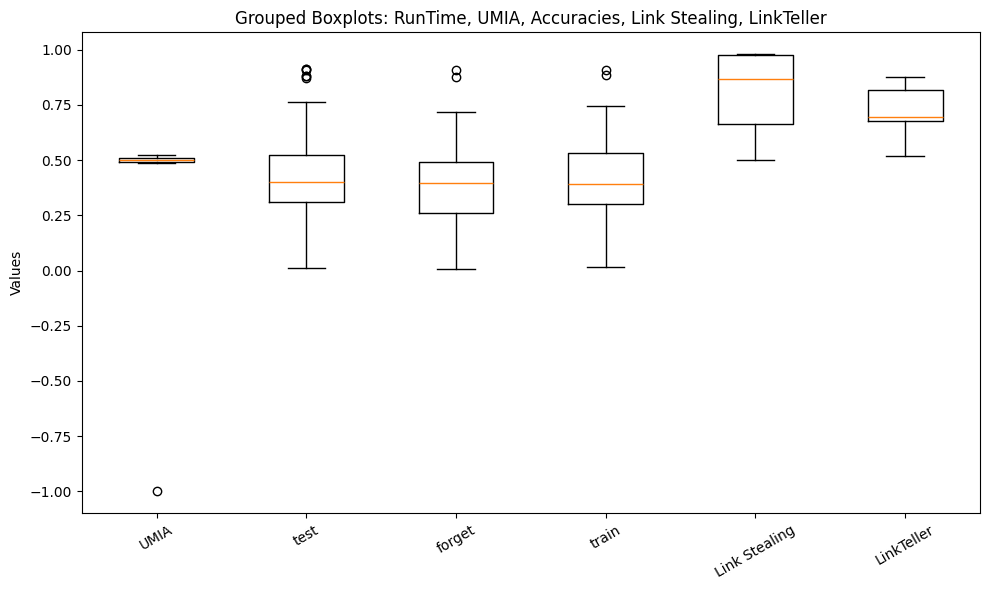

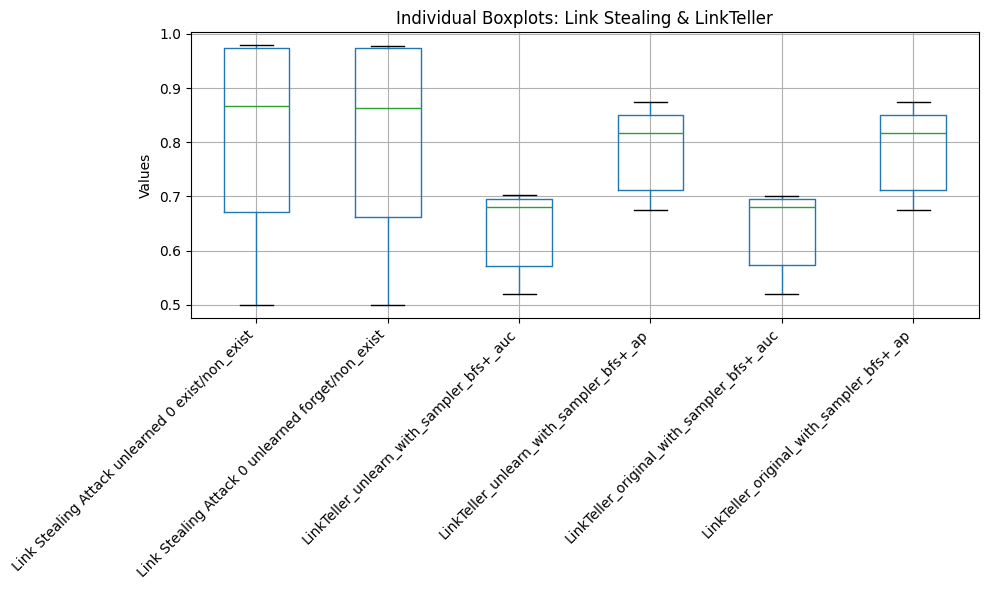

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- Grouped plot as before ---
groups = {
    "UMIA": ["UMIA"],
    "test": [
        "sklearn.metrics.accuracy_score.test.unlearned.on_graph:True",
        "sklearn.metrics.accuracy_score.test.unlearned.on_graph:False",
        "sklearn.metrics.accuracy_score.test.original.on_graph:False",
    ],
    "forget": ["sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True"],
    "train": ["sklearn.metrics.accuracy_score.train.unlearned.on_graph:True"],
    "Link Stealing": [
        "Link Stealing Attack unlearned 0 exist/non_exist",
        "Link Stealing Attack 0 unlearned forget/non_exist",
    ],
    "LinkTeller": [
        "LinkTeller_unlearn_with_sampler_bfs+_auc",
        "LinkTeller_unlearn_with_sampler_bfs+_ap",
        "LinkTeller_original_with_sampler_bfs+_auc",
        "LinkTeller_original_with_sampler_bfs+_ap",
    ],
}

# Build grouped data
grouped_data = []
grouped_labels = []
for label, cols in groups.items():
    vals = np.concatenate([csv[c].dropna().values for c in cols])
    grouped_data.append(vals)
    grouped_labels.append(label)
    

# Plot grouped boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(grouped_data, labels=grouped_labels)
plt.title("Grouped Boxplots: RunTime, UMIA, Accuracies, Link Stealing, LinkTeller")
plt.ylabel("Values")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# --- Individual plot for Link Stealing & LinkTeller ---
individual_cols = groups["Link Stealing"] + groups["LinkTeller"]

plt.figure(figsize=(10, 6))
csv[individual_cols].boxplot()
plt.title("Individual Boxplots: Link Stealing & LinkTeller")
plt.ylabel("Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
